In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser

In [2]:
df = pd.read_csv('archive/1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
close_prices = df['close'].values

In [3]:
df.head()

,Unnamed: 0,open,high,low,close,volume,barCount,average
date,,,,,,,,
2009-05-22 07:30:00,0,89.45,89.46,89.37,89.37,7872,2102,89.424
2009-05-22 07:31:00,1,89.38,89.53,89.37,89.50,5336,1938,89.468
2009-05-22 07:32:00,2,89.51,89.54,89.48,89.49,3349,1184,89.516
2009-05-22 07:33:00,3,89.49,89.49,89.31,89.34,3495,1240,89.386
2009-05-22 07:34:00,4,89.33,89.46,89.33,89.39,9731,2637,89.379


Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


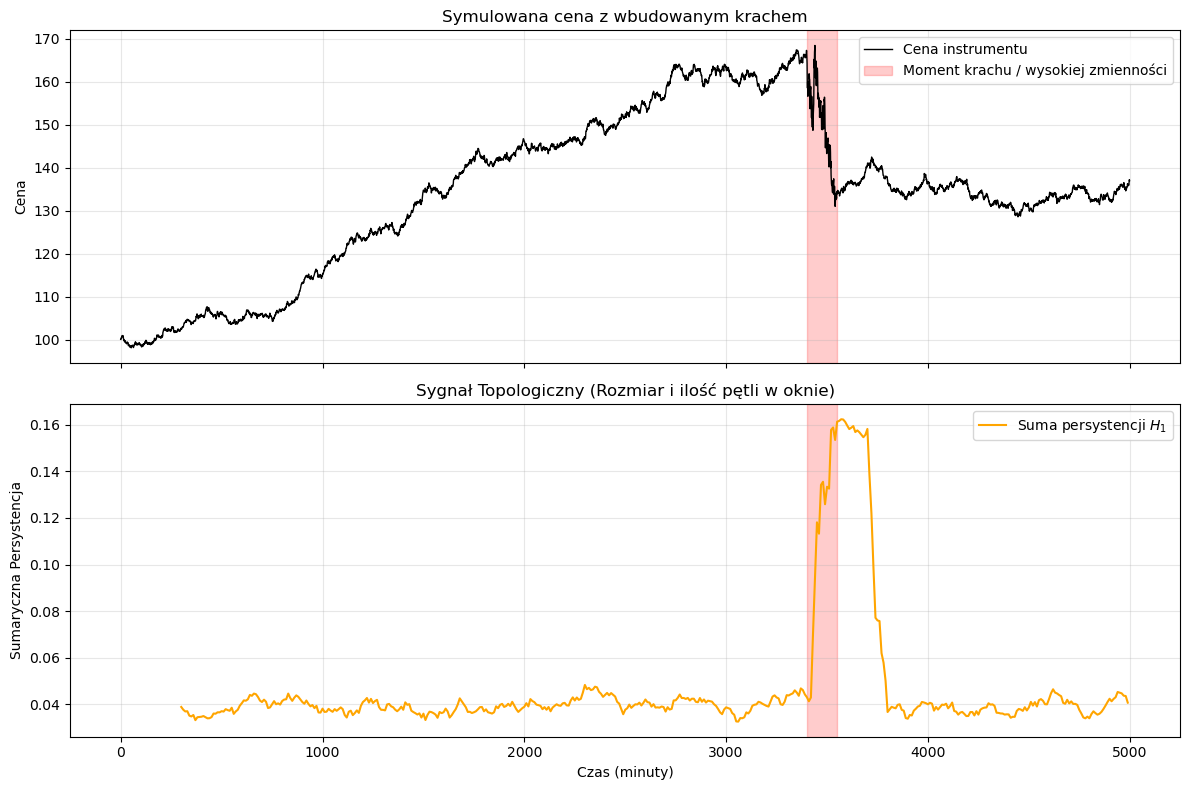

In [ ]:
def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Wycinamy przesunięte wektory
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded



# Na potrzeby testu kodu generujemy syntetyczny geometryczny ruch Browna z "krachem"
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))

# Obliczamy log-zwroty
log_returns = np.diff(np.log(close_prices))

# 3. Parametry eksperymentu
window_size = 300    # Długość kroczącego okna w minutach
delay = 2            # Opóźnienie (tau) w zanurzeniu Takensa
dimension = 4        # Wymiar chmury punktów (d)
step = 10            # Przesuwamy okno co 10 minut (dla przyspieszenia obliczeń)

# Tablice na wyniki
timestamps = []
h1_total_persistence = []

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# 4. Główna pętla
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    # Tworzymy chmurę punktów
    point_cloud = takens_embedding(window_data, delay, dimension)
    
    if len(point_cloud) < dimension + 1:
        continue # Pomijamy, jeśli mamy za mało punktów
        
    # Obliczamy homologię persystentną (interesuje nas max wymiar 1)
    # ripser radzi sobie najlepiej z macierzami odległości, 
    # ale przyjmuje też chmury punktów i sam liczy metrykę euklidesową
    res = ripser(point_cloud, maxdim=1)
    diagrams = res['dgms']
    
    # Diagram dla H_1 (pętle)
    h1_diagram = diagrams[1]
    
    if len(h1_diagram) > 0:
        # Filtrujemy cechy o nieskończonym czasie życia (choć w H_1 rzadkie)
        valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
        if len(valid_features) > 0:
            # Obliczamy "czas życia" (death - birth) każdej pętli
            lifespans = valid_features[:, 1] - valid_features[:, 0]
            # Sumujemy czasy życia jako prostą miarę (proxy entropii L1)
            total_pers = np.sum(lifespans)
        else:
            total_pers = 0.0
    else:
        total_pers = 0.0
        
    h1_total_persistence.append(total_pers)
    # Zapisujemy indeks środka lub końca okna do wykresu
    timestamps.append(i + window_size)

print("Obliczenia zakończone.")

# 5. Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnału topologicznego
ax2.plot(timestamps, h1_total_persistence, label='Suma persystencji $H_1$', color='orange', linewidth=1.5)
ax2.set_title('Sygnał Topologiczny (Rozmiar i ilość pętli w oknie)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rozpoczynam obliczenia TDA dla 4699 okien i 6 wymiarów...
Obliczenia zakończone. Generowanie wykresu...


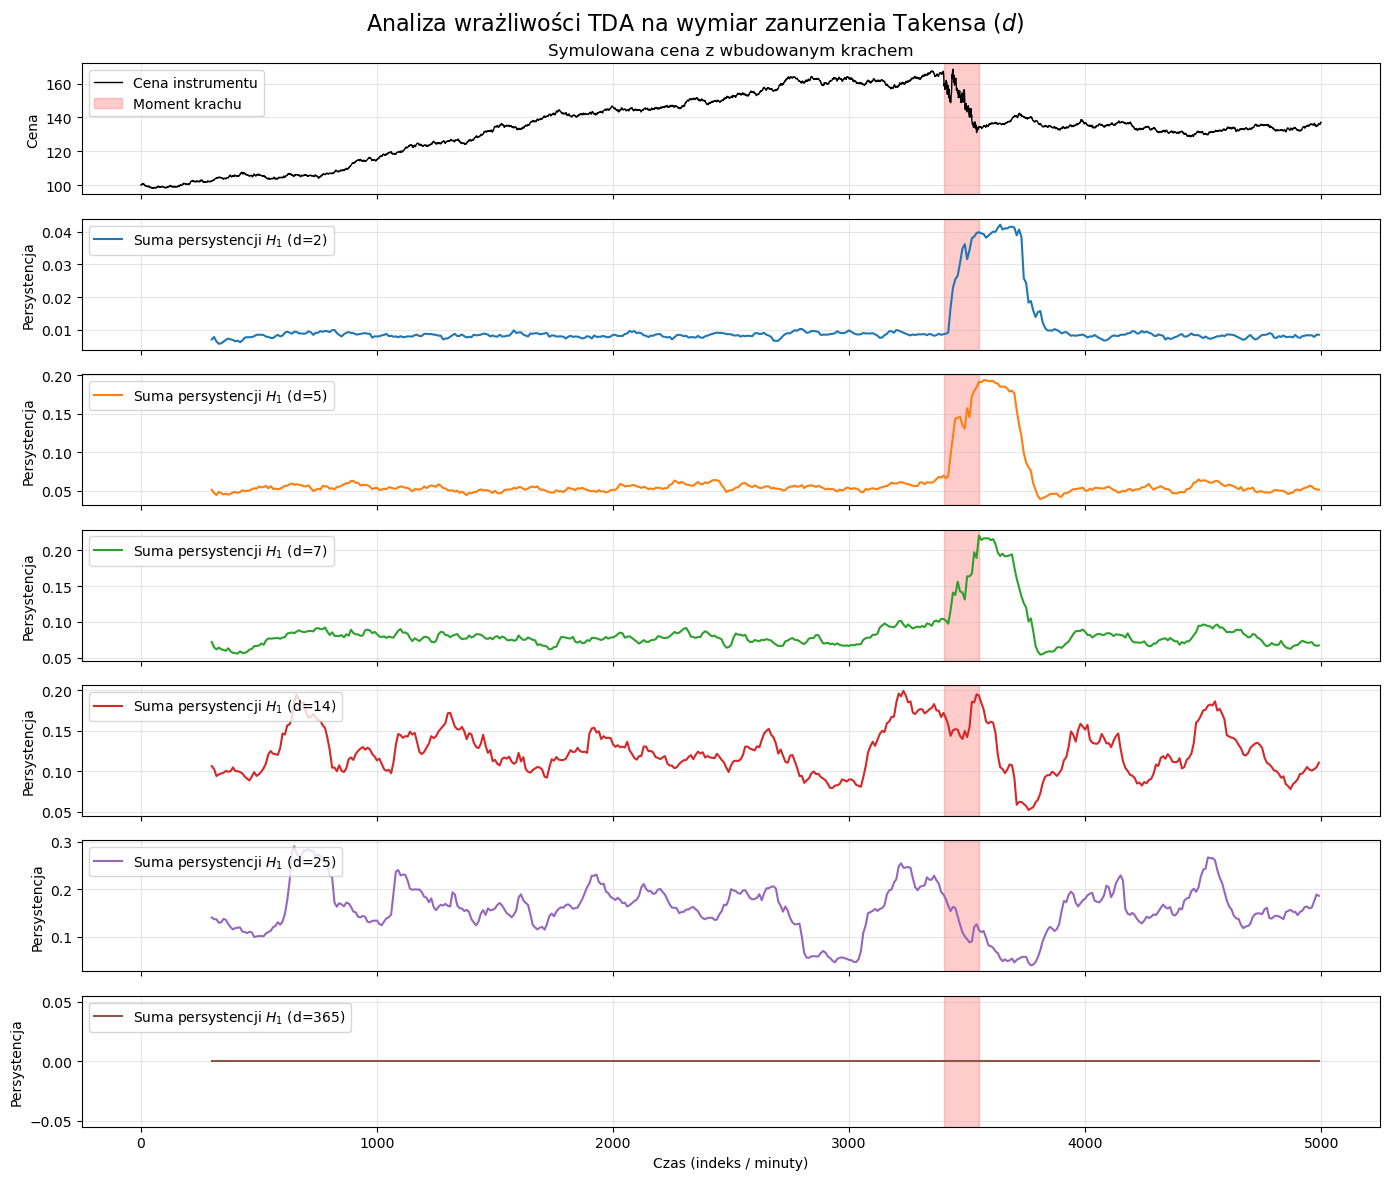

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser

def takens_embedding(series, delay, dimension):
    """
    Tworzy chmurę punktów z jednowymiarowego szeregu czasowego.
    """
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

# 1. Generowanie danych (geometryczny ruch Browna z krachem)
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu
crash_start, crash_end = 3400, 3550
returns[crash_start:crash_end] = np.random.normal(-0.002, 0.015, crash_end - crash_start) 
close_prices = 100 * np.exp(np.cumsum(returns))
log_returns = np.diff(np.log(close_prices))

# 2. Parametry eksperymentu
window_size = 300    # Długość okna
delay = 2            # Opóźnienie (tau)
step = 10            # Przesunięcie okna
dimensions_to_test = [2,5,7,14,25,365] # Testowane wymiary zanurzenia

timestamps = []
# Słownik do przechowywania wyników dla każdego wymiaru
results_h1 = {d: [] for d in dimensions_to_test}

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien i {len(dimensions_to_test)} wymiarów...")

# 3. Główna pętla
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    timestamps.append(i + window_size)
    
    for d in dimensions_to_test:
        point_cloud = takens_embedding(window_data, delay, d)
        
        if len(point_cloud) < d + 1:
            results_h1[d].append(0.0)
            continue
            
        # Obliczamy homologię persystentną
        res = ripser(point_cloud, maxdim=1)
        diagrams = res['dgms']
        h1_diagram = diagrams[1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        results_h1[d].append(total_pers)

print("Obliczenia zakończone. Generowanie wykresu...")

# 4. Wizualizacja
fig, axes = plt.subplots(len(dimensions_to_test) + 1, 1, figsize=(14, 12), sharex=True)

# Wykres cen (pierwszy na górze)
axes[0].plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
axes[0].axvspan(crash_start, crash_end, color='red', alpha=0.2, label='Moment krachu')
axes[0].set_title('Symulowana cena z wbudowanym krachem')
axes[0].set_ylabel('Cena')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Wykresy sygnałów topologicznych dla kolejnych wymiarów
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', "#8c564b", "#e377c2", "#7f7f7f"]

for idx, d in enumerate(dimensions_to_test):
    ax = axes[idx + 1]
    ax.plot(timestamps, results_h1[d], label=f'Suma persystencji $H_1$ (d={d})', color=colors[idx], linewidth=1.5)
    ax.axvspan(crash_start, crash_end, color='red', alpha=0.2)
    ax.set_ylabel('Persystencja')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Czas (indeks / minuty)')
plt.suptitle('Analiza wrażliwości TDA na wymiar zanurzenia Takensa ($d$)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


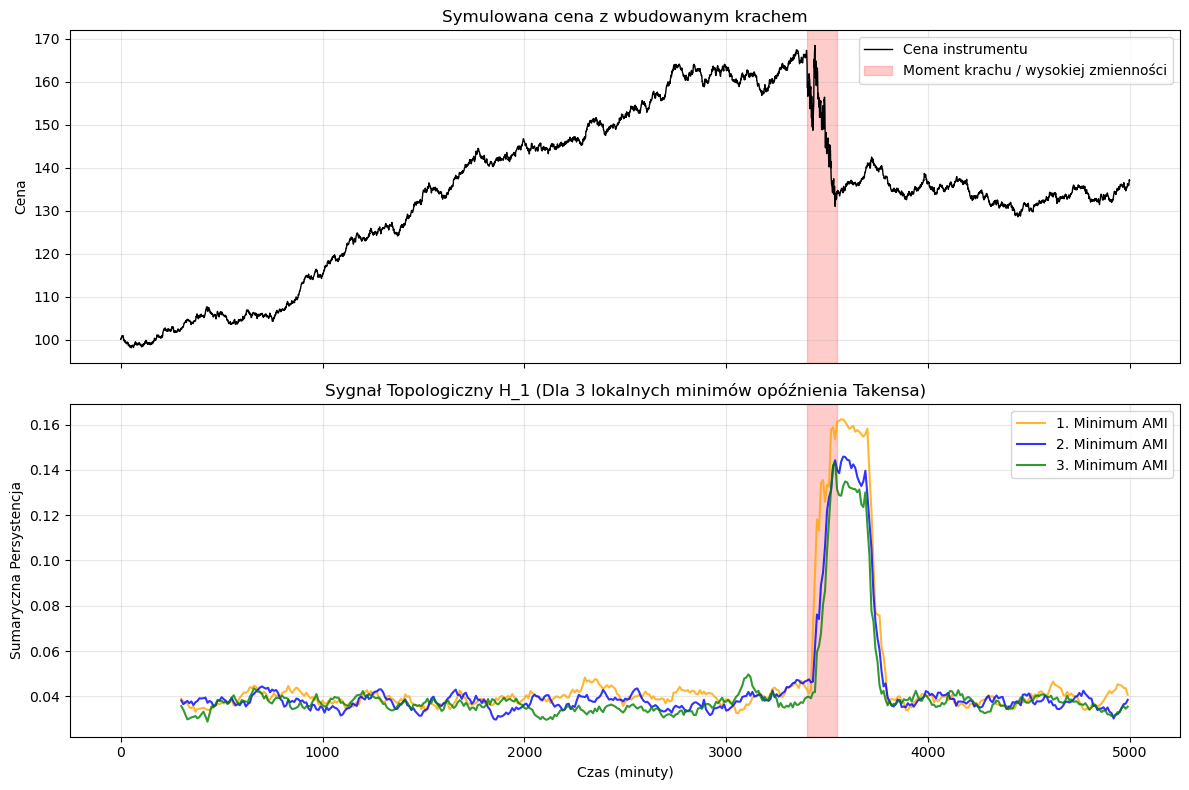

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from sklearn.metrics import mutual_info_score
from scipy.signal import find_peaks

# ==========================================
# 1. Funkcje Pomocnicze (Takens & AMI)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Zoptymalizowane wycinanie przesuniętych wektorów
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

def compute_ami(series, max_delay, bins=20):
    """Oblicza Average Mutual Information dla opóźnień od 1 do max_delay."""
    amis = []
    for tau in range(1, max_delay + 1):
        x = series[:-tau]
        y = series[tau:]
        
        # Szybkie liczenie AMI za pomocą histogramu 2D (contingency table)
        c_xy, _, _ = np.histogram2d(x, y, bins=bins)
        mi = mutual_info_score(None, None, contingency=c_xy)
        amis.append(mi)
        
    return np.array(amis)

def find_top_ami_delays(series, max_delay=30, num_peaks=3):
    """Znajduje do 'num_peaks' lokalnych minimów funkcji AMI."""
    ami_values = compute_ami(series, max_delay)
    
    # Szukamy dołków (lokalnych minimów), więc odwracamy znak tablicy
    # distance=2 zapewnia, że minima nie będą tuż obok siebie (np. tau=3 i tau=4)
    minima_indices, _ = find_peaks(-ami_values, distance=2)
    
    # Przesuwamy o +1, bo indeks 0 odpowiada tau=1
    delays = minima_indices + 1
    
    # Jeśli algorytm znajdzie mniej minimów, uzupełniamy brakujące standardowymi wartościami (np. 1, 2)
    if len(delays) == 0:
        return [1, 2, 3][:num_peaks]
    
    # Zwracamy tylko wymaganą liczbę pierwszych minimów
    return delays[:num_peaks].tolist()


# ==========================================
# 2. Generowanie Danych (Geometryczny Ruch Browna)
# ==========================================
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))
log_returns = np.diff(np.log(close_prices))


# ==========================================
# 3. Parametry eksperymentu
# ==========================================
window_size = 300    
dimension = 4        
step = 10            
max_ami_search = 30  # Szukamy minimów w oknie do tau=30

timestamps = []
# Słownik do przechowywania wyników dla 3 różnych opóźnień
h1_persistence_results = {0: [], 1: [], 2: []} 

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# ==========================================
# 4. Główna pętla z analizą 3 osadzeń
# ==========================================
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    # 4A. Dynamiczne szukanie optymalnych opóźnień dla obecnego okna
    # Zwraca listę np. [3, 7, 12]
    optimal_taus = [2, 5, 10]

    timestamps.append(i + window_size)
    
    # 4B. Obliczamy TDA dla każdego z 3 wyłonionych opóźnień
    for idx, tau in enumerate(optimal_taus):
        point_cloud = takens_embedding(window_data, tau, dimension)
        
        if len(point_cloud) < dimension + 1:
            h1_persistence_results[idx].append(0.0)
            continue
            
        res = ripser(point_cloud, maxdim=1)
        h1_diagram = res['dgms'][1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        h1_persistence_results[idx].append(total_pers)

print("Obliczenia zakończone.")

# ==========================================
# 5. Wizualizacja
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnałów topologicznych dla 3 różnych minimów AMI
colors = ['orange', 'blue', 'green']
labels = ['1. Minimum AMI', '2. Minimum AMI', '3. Minimum AMI']

for idx in range(3):
    ax2.plot(timestamps, h1_persistence_results[idx], label=labels[idx], color=colors[idx], linewidth=1.5, alpha=0.8)

ax2.set_title(f'Sygnał Topologiczny H_1 (Dla 3 lokalnych minimów opóźnienia Takensa)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Wczytywanie danych...
Rozpoczynam obliczenia TDA dla 328118 punktów. Liczba okien: 32781
Krok 0... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 100... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 200... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 300... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 400... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 500... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 600... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 700... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 800... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 900... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1000... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1100... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1200... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1300... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1400... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1500... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 1600... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 

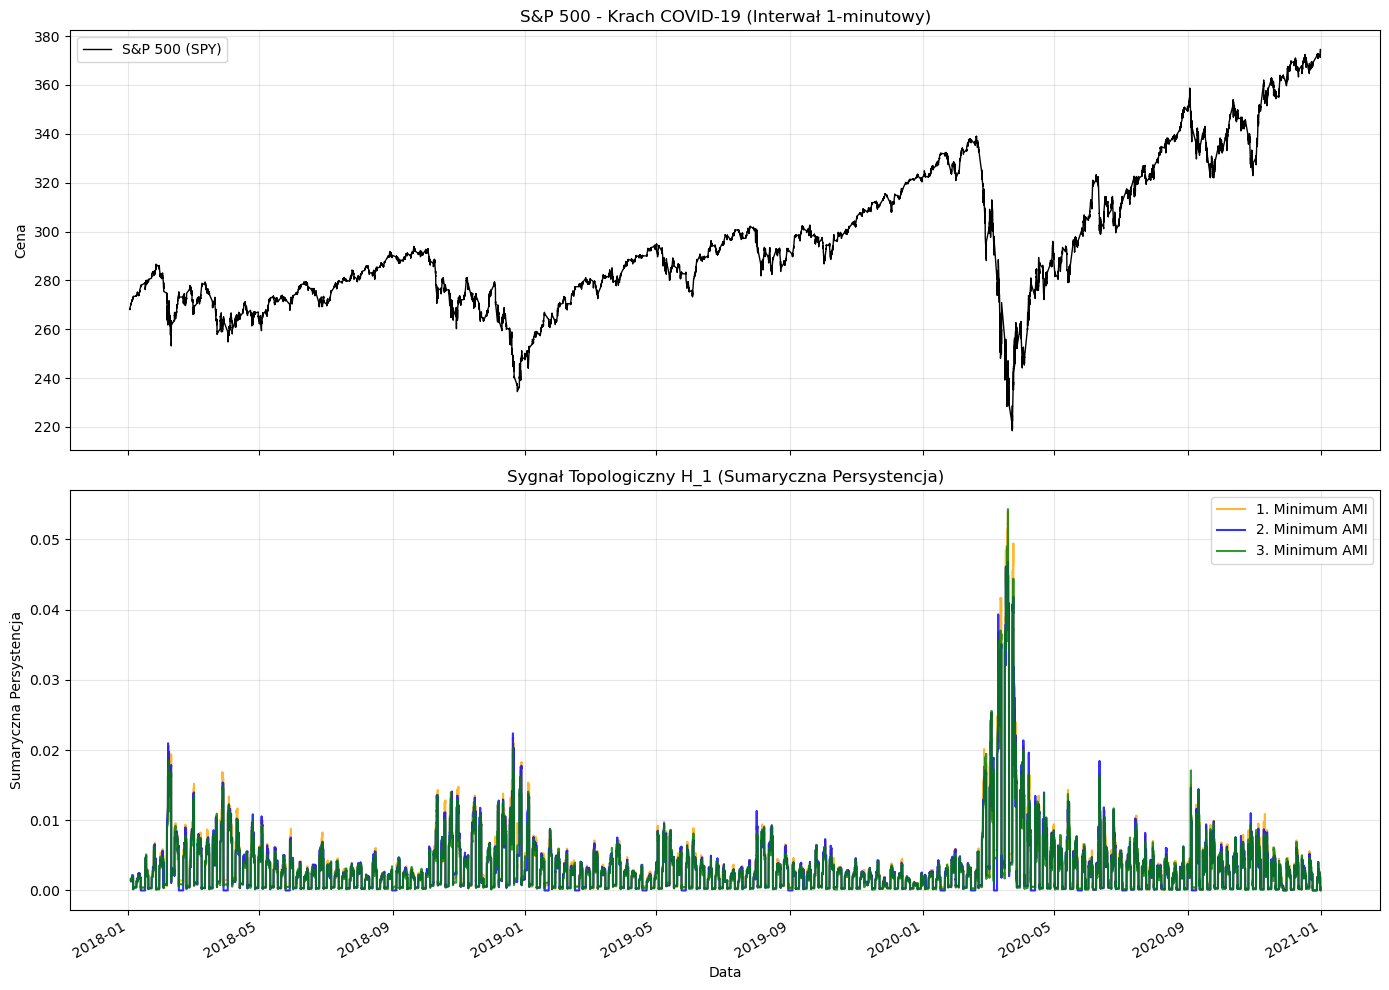

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from sklearn.metrics import mutual_info_score
from scipy.signal import find_peaks
import time

# ==========================================
# 1. Funkcje Pomocnicze (Takens & AMI)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

def compute_ami(series, max_delay, bins=20):
    amis = []
    for tau in range(1, max_delay + 1):
        x = series[:-tau]
        y = series[tau:]
        c_xy, _, _ = np.histogram2d(x, y, bins=bins)
        mi = mutual_info_score(None, None, contingency=c_xy)
        amis.append(mi)
    return np.array(amis)

def find_top_ami_delays(series, max_delay=30, num_peaks=3):
    ami_values = compute_ami(series, max_delay)
    minima_indices, _ = find_peaks(-ami_values, distance=2)
    delays = minima_indices + 1
    
    if len(delays) == 0:
        return [1, 2, 3][:num_peaks]
    
    return delays[:num_peaks].tolist()

# ==========================================
# 2. Przygotowanie Prawdziwych Danych
# ==========================================
print("Wczytywanie danych...")
# Zakładam, że plik jest w tym samym folderze
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')

# KLUCZOWE: Sortowanie indeksu i filtrowanie tylko godzin handlu
df = df.sort_index()
df = df.between_time('09:30', '16:00')

# Wycinamy krach z początku pandemii COVID-19 (Luty - Marzec 2020)
# Jeśli chcesz puścić na całości (ryzyko bardzo długich obliczeń!), 
# zakomentuj tę linijkę i użyj: df_crash = df.copy()
df_crash = df.loc['2018-01-01':'2020-12-31'].copy()
# df_crash = df.copy()


close_prices = df_crash['close'].values
log_returns = np.diff(np.log(close_prices))
dates = df_crash.index[1:]

# ==========================================
# 3. Parametry eksperymentu
# ==========================================
window_size = 300    # ok. 5 godzin handlu
dimension = 4        
step = 10            # krok przesuwania okna
max_ami_search = 30  

timestamps = []
h1_persistence_results = {0: [], 1: [], 2: []} 

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns)} punktów. Liczba okien: {(len(log_returns) - window_size) // step}")
start_time = time.time()

# ==========================================
# 4. Główna pętla z analizą 3 osadzeń
# ==========================================
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    optimal_taus = [2, 5, 10]  # Stałe opóźnienia dla przykładu

    timestamps.append(dates[i + window_size])
    
    # Co 100 iteracji wypisujemy status i dobrane opóźnienia AMI
    if (i // step) % 100 == 0:
        print(f"Krok {i // step}... Wybrane opóźnienia AMI (tau): {optimal_taus}")
    
    for idx, tau in enumerate(optimal_taus):
        point_cloud = takens_embedding(window_data, tau, dimension)
        
        if len(point_cloud) < dimension + 1:
            h1_persistence_results[idx].append(0.0)
            continue
            
        res = ripser(point_cloud, maxdim=1)
        h1_diagram = res['dgms'][1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        h1_persistence_results[idx].append(total_pers)

print(f"Obliczenia zakończone w {time.time() - start_time:.2f} sekund.")

# ==========================================
# 5. Wizualizacja
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Wykres cen
ax1.plot(dates, close_prices[1:], label='S&P 500 (SPY)', color='black', linewidth=1)
ax1.set_title('S&P 500 - Krach COVID-19 (Interwał 1-minutowy)')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnałów topologicznych
colors = ['orange', 'blue', 'green']
labels = ['1. Minimum AMI', '2. Minimum AMI', '3. Minimum AMI']

for idx in range(3):
    ax2.plot(timestamps, h1_persistence_results[idx], label=labels[idx], color=colors[idx], linewidth=1.5, alpha=0.8)

ax2.set_title(f'Sygnał Topologiczny H_1 (Sumaryczna Persystencja)')
ax2.set_xlabel('Data')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Formatowanie osi X pod daty
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

Wczytywanie danych...
Rozpoczynam obliczenia TDA dla 328118 punktów. Liczba okien: 32781
Krok 0... Wybrane opóźnienia AMI (tau): [3, 8, 12]
Krok 100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 200... Wybrane opóźnienia AMI (tau): [5, 11, 14]
Krok 300... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 400... Wybrane opóźnienia AMI (tau): [3, 6, 10]
Krok 500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 600... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 700... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 800... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 900... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 1000... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 1100... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 1200... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 1300... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 1400... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 1500... Wybrane opóźnienia AMI (tau): [4, 8, 12]
Krok 1600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 1700... 

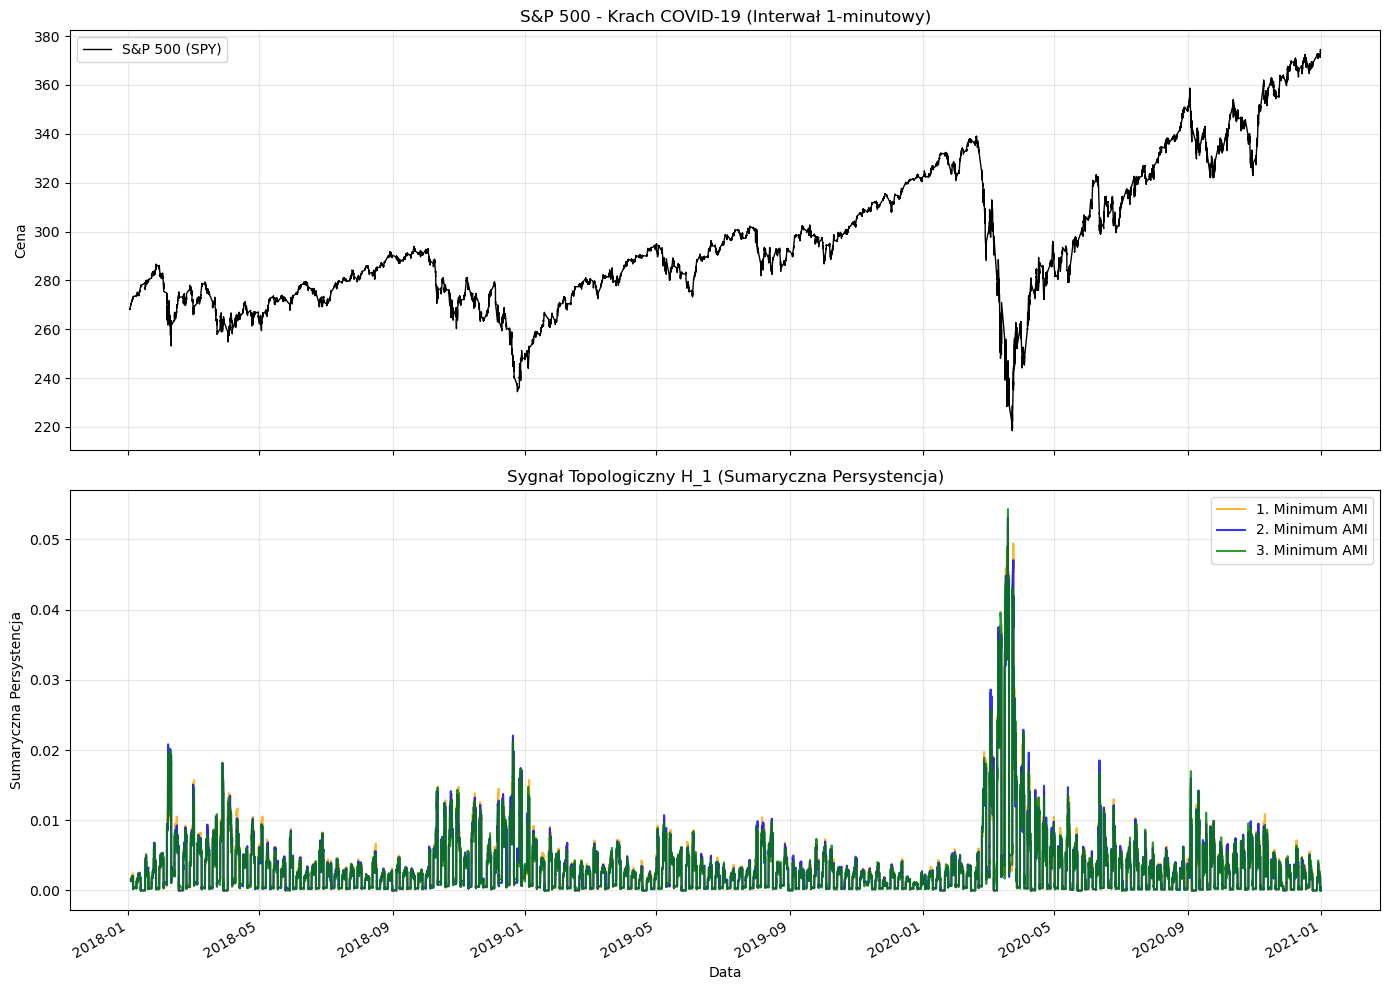

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from sklearn.metrics import mutual_info_score
from scipy.signal import find_peaks
import time

# ==========================================
# 1. Funkcje Pomocnicze (Takens & AMI)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

def compute_ami(series, max_delay, bins=20):
    amis = []
    for tau in range(1, max_delay + 1):
        x = series[:-tau]
        y = series[tau:]
        c_xy, _, _ = np.histogram2d(x, y, bins=bins)
        mi = mutual_info_score(None, None, contingency=c_xy)
        amis.append(mi)
    return np.array(amis)

def find_top_ami_delays(series, max_delay=30, num_peaks=3):
    ami_values = compute_ami(series, max_delay)
    minima_indices, _ = find_peaks(-ami_values, distance=2)
    delays = minima_indices + 1
    
    if len(delays) == 0:
        return [1, 2, 3][:num_peaks]
    
    return delays[:num_peaks].tolist()

# ==========================================
# 2. Przygotowanie Prawdziwych Danych
# ==========================================
print("Wczytywanie danych...")
# Zakładam, że plik jest w tym samym folderze
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')

# KLUCZOWE: Sortowanie indeksu i filtrowanie tylko godzin handlu
df = df.sort_index()
df = df.between_time('09:30', '16:00')

# Wycinamy krach z początku pandemii COVID-19 (Luty - Marzec 2020)
# Jeśli chcesz puścić na całości (ryzyko bardzo długich obliczeń!), 
# zakomentuj tę linijkę i użyj: df_crash = df.copy()
df_crash = df.loc['2018-01-01':'2020-12-31'].copy()
# df_crash = df.copy()


close_prices = df_crash['close'].values
log_returns = np.diff(np.log(close_prices))
dates = df_crash.index[1:]

# ==========================================
# 3. Parametry eksperymentu
# ==========================================
window_size = 300    # ok. 5 godzin handlu
dimension = 4        
step = 10            # krok przesuwania okna
max_ami_search = 30  

timestamps = []
h1_persistence_results = {0: [], 1: [], 2: []} 

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns)} punktów. Liczba okien: {(len(log_returns) - window_size) // step}")
start_time = time.time()

# ==========================================
# 4. Główna pętla z analizą 3 osadzeń
# ==========================================
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    optimal_taus = find_top_ami_delays(window_data, max_delay=max_ami_search, num_peaks=3)
    while len(optimal_taus) < 3:
        optimal_taus.append(optimal_taus[-1] + 1)
        
    timestamps.append(dates[i + window_size])
    
    # Co 100 iteracji wypisujemy status i dobrane opóźnienia AMI
    if (i // step) % 100 == 0:
        print(f"Krok {i // step}... Wybrane opóźnienia AMI (tau): {optimal_taus}")
    
    for idx, tau in enumerate(optimal_taus):
        point_cloud = takens_embedding(window_data, tau, dimension)
        
        if len(point_cloud) < dimension + 1:
            h1_persistence_results[idx].append(0.0)
            continue
            
        res = ripser(point_cloud, maxdim=1)
        h1_diagram = res['dgms'][1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        h1_persistence_results[idx].append(total_pers)

print(f"Obliczenia zakończone w {time.time() - start_time:.2f} sekund.")

# ==========================================
# 5. Wizualizacja
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Wykres cen
ax1.plot(dates, close_prices[1:], label='S&P 500 (SPY)', color='black', linewidth=1)
ax1.set_title('S&P 500 - Krach COVID-19 (Interwał 1-minutowy)')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnałów topologicznych
colors = ['orange', 'blue', 'green']
labels = ['1. Minimum AMI', '2. Minimum AMI', '3. Minimum AMI']

for idx in range(3):
    ax2.plot(timestamps, h1_persistence_results[idx], label=labels[idx], color=colors[idx], linewidth=1.5, alpha=0.8)

ax2.set_title(f'Sygnał Topologiczny H_1 (Sumaryczna Persystencja)')
ax2.set_xlabel('Data')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Formatowanie osi X pod daty
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [3]:
import re
from collections import Counter

# Wklej tutaj CAŁY swój output z konsoli pomiędzy potrójne cudzysłowy
log_data = """
Wczytywanie danych...
Rozpoczynam obliczenia TDA dla 328118 punktów. Liczba okien: 32781
Krok 0... Wybrane opóźnienia AMI (tau): [3, 8, 12]
Krok 100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 200... Wybrane opóźnienia AMI (tau): [5, 11, 14]
Krok 300... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 400... Wybrane opóźnienia AMI (tau): [3, 6, 10]
Krok 500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 600... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 700... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 800... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 900... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 1000... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 1100... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 1200... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 1300... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 1400... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 1500... Wybrane opóźnienia AMI (tau): [4, 8, 12]
Krok 1600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 1700... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 1800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 1900... Wybrane opóźnienia AMI (tau): [4, 6, 9]
Krok 2000... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 2100... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 2200... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 2300... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 2400... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 2500... Wybrane opóźnienia AMI (tau): [2, 6, 8]
Krok 2600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 2700... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 2800... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 2900... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 3000... Wybrane opóźnienia AMI (tau): [2, 6, 10]
Krok 3100... Wybrane opóźnienia AMI (tau): [5, 7, 10]
Krok 3200... Wybrane opóźnienia AMI (tau): [4, 9, 12]
Krok 3300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 3400... Wybrane opóźnienia AMI (tau): [3, 6, 10]
Krok 3500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 3600... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 3700... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 3800... Wybrane opóźnienia AMI (tau): [3, 7, 9]
Krok 3900... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 4000... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 4100... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 4200... Wybrane opóźnienia AMI (tau): [4, 7, 11]
Krok 4300... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 4400... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 4500... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 4600... Wybrane opóźnienia AMI (tau): [5, 8, 10]
Krok 4700... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 4800... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 4900... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 5000... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 5100... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 5200... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 5300... Wybrane opóźnienia AMI (tau): [3, 7, 10]
Krok 5400... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 5500... Wybrane opóźnienia AMI (tau): [6, 8, 10]
Krok 5600... Wybrane opóźnienia AMI (tau): [5, 8, 10]
Krok 5700... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 5800... Wybrane opóźnienia AMI (tau): [2, 6, 10]
Krok 5900... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 6000... Wybrane opóźnienia AMI (tau): [4, 6, 9]
Krok 6100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 6200... Wybrane opóźnienia AMI (tau): [3, 8, 12]
Krok 6300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 6400... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 6500... Wybrane opóźnienia AMI (tau): [3, 7, 11]
Krok 6600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 6700... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 6800... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 6900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 7000... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 7100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 7200... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 7300... Wybrane opóźnienia AMI (tau): [2, 6, 11]
Krok 7400... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 7500... Wybrane opóźnienia AMI (tau): [4, 7, 11]
Krok 7600... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 7700... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 7800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 7900... Wybrane opóźnienia AMI (tau): [2, 6, 8]
Krok 8000... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 8100... Wybrane opóźnienia AMI (tau): [2, 4, 9]
Krok 8200... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 8300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 8400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 8500... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 8600... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 8700... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 8800... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 8900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 9000... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 9100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 9200... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 9300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 9400... Wybrane opóźnienia AMI (tau): [2, 7, 9]
Krok 9500... Wybrane opóźnienia AMI (tau): [2, 8, 10]
Krok 9600... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 9700... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 9800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 9900... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 10000... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 10100... Wybrane opóźnienia AMI (tau): [4, 6, 11]
Krok 10200... Wybrane opóźnienia AMI (tau): [3, 7, 10]
Krok 10300... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 10400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 10500... Wybrane opóźnienia AMI (tau): [2, 5, 9]
Krok 10600... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 10700... Wybrane opóźnienia AMI (tau): [2, 6, 8]
Krok 10800... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 10900... Wybrane opóźnienia AMI (tau): [5, 7, 11]
Krok 11000... Wybrane opóźnienia AMI (tau): [3, 7, 9]
Krok 11100... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 11200... Wybrane opóźnienia AMI (tau): [4, 9, 11]
Krok 11300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 11400... Wybrane opóźnienia AMI (tau): [3, 8, 10]
Krok 11500... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 11600... Wybrane opóźnienia AMI (tau): [2, 6, 13]
Krok 11700... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 11800... Wybrane opóźnienia AMI (tau): [7, 9, 13]
Krok 11900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 12000... Wybrane opóźnienia AMI (tau): [3, 6, 9]
Krok 12100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 12200... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 12300... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 12400... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 12500... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 12600... Wybrane opóźnienia AMI (tau): [3, 7, 11]
Krok 12700... Wybrane opóźnienia AMI (tau): [4, 6, 10]
Krok 12800... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 12900... Wybrane opóźnienia AMI (tau): [2, 6, 9]
Krok 13000... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 13100... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 13200... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 13300... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 13400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 13500... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 13600... Wybrane opóźnienia AMI (tau): [3, 7, 11]
Krok 13700... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 13800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 13900... Wybrane opóźnienia AMI (tau): [4, 6, 8]
Krok 14000... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 14100... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 14200... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 14300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 14400... Wybrane opóźnienia AMI (tau): [5, 7, 10]
Krok 14500... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 14600... Wybrane opóźnienia AMI (tau): [4, 6, 9]
Krok 14700... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 14800... Wybrane opóźnienia AMI (tau): [2, 6, 10]
Krok 14900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 15000... Wybrane opóźnienia AMI (tau): [5, 7, 11]
Krok 15100... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 15200... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 15300... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 15400... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 15500... Wybrane opóźnienia AMI (tau): [3, 8, 11]
Krok 15600... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 15700... Wybrane opóźnienia AMI (tau): [4, 10, 13]
Krok 15800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 15900... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 16000... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 16100... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 16200... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 16300... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 16400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 16500... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 16600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 16700... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 16800... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 16900... Wybrane opóźnienia AMI (tau): [3, 9, 12]
Krok 17000... Wybrane opóźnienia AMI (tau): [5, 7, 11]
Krok 17100... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 17200... Wybrane opóźnienia AMI (tau): [2, 8, 11]
Krok 17300... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 17400... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 17500... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 17600... Wybrane opóźnienia AMI (tau): [2, 9, 13]
Krok 17700... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 17800... Wybrane opóźnienia AMI (tau): [4, 6, 9]
Krok 17900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 18000... Wybrane opóźnienia AMI (tau): [4, 8, 12]
Krok 18100... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 18200... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 18300... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 18400... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 18500... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 18600... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 18700... Wybrane opóźnienia AMI (tau): [2, 5, 10]
Krok 18800... Wybrane opóźnienia AMI (tau): [5, 7, 10]
Krok 18900... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 19000... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 19100... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 19200... Wybrane opóźnienia AMI (tau): [3, 8, 10]
Krok 19300... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 19400... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 19500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 19600... Wybrane opóźnienia AMI (tau): [3, 5, 9]
Krok 19700... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 19800... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 19900... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 20000... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 20100... Wybrane opóźnienia AMI (tau): [3, 6, 9]
Krok 20200... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 20300... Wybrane opóźnienia AMI (tau): [3, 7, 10]
Krok 20400... Wybrane opóźnienia AMI (tau): [5, 7, 11]
Krok 20500... Wybrane opóźnienia AMI (tau): [3, 5, 11]
Krok 20600... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 20700... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 20800... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 20900... Wybrane opóźnienia AMI (tau): [3, 6, 9]
Krok 21000... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 21100... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 21200... Wybrane opóźnienia AMI (tau): [3, 7, 11]
Krok 21300... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 21400... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 21500... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 21600... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 21700... Wybrane opóźnienia AMI (tau): [5, 8, 11]
Krok 21800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 21900... Wybrane opóźnienia AMI (tau): [2, 5, 9]
Krok 22000... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 22100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 22200... Wybrane opóźnienia AMI (tau): [3, 7, 9]
Krok 22300... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 22400... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 22500... Wybrane opóźnienia AMI (tau): [2, 7, 9]
Krok 22600... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 22700... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 22800... Wybrane opóźnienia AMI (tau): [3, 8, 11]
Krok 22900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 23000... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 23100... Wybrane opóźnienia AMI (tau): [3, 6, 12]
Krok 23200... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 23300... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 23400... Wybrane opóźnienia AMI (tau): [3, 8, 12]
Krok 23500... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 23600... Wybrane opóźnienia AMI (tau): [5, 7, 9]
Krok 23700... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 23800... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 23900... Wybrane opóźnienia AMI (tau): [5, 10, 13]
Krok 24000... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 24100... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 24200... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 24300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 24400... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 24500... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 24600... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 24700... Wybrane opóźnienia AMI (tau): [3, 6, 9]
Krok 24800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 24900... Wybrane opóźnienia AMI (tau): [4, 7, 11]
Krok 25000... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 25100... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 25200... Wybrane opóźnienia AMI (tau): [2, 4, 9]
Krok 25300... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 25400... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 25500... Wybrane opóźnienia AMI (tau): [3, 5, 9]
Krok 25600... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 25700... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 25800... Wybrane opóźnienia AMI (tau): [5, 8, 10]
Krok 25900... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 26000... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 26100... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 26200... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 26300... Wybrane opóźnienia AMI (tau): [3, 7, 10]
Krok 26400... Wybrane opóźnienia AMI (tau): [5, 7, 12]
Krok 26500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 26600... Wybrane opóźnienia AMI (tau): [2, 6, 8]
Krok 26700... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 26800... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 26900... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 27000... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 27100... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 27200... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 27300... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 27400... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 27500... Wybrane opóźnienia AMI (tau): [4, 9, 12]
Krok 27600... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 27700... Wybrane opóźnienia AMI (tau): [3, 6, 10]
Krok 27800... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 27900... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 28000... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 28100... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 28200... Wybrane opóźnienia AMI (tau): [5, 9, 13]
Krok 28300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 28400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 28500... Wybrane opóźnienia AMI (tau): [4, 8, 10]
Krok 28600... Wybrane opóźnienia AMI (tau): [3, 6, 9]
Krok 28700... Wybrane opóźnienia AMI (tau): [5, 7, 10]
Krok 28800... Wybrane opóźnienia AMI (tau): [3, 7, 9]
Krok 28900... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 29000... Wybrane opóźnienia AMI (tau): [2, 4, 8]
Krok 29100... Wybrane opóźnienia AMI (tau): [3, 5, 9]
Krok 29200... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 29300... Wybrane opóźnienia AMI (tau): [5, 8, 12]
Krok 29400... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 29500... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 29600... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 29700... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 29800... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 29900... Wybrane opóźnienia AMI (tau): [2, 4, 6]
Krok 30000... Wybrane opóźnienia AMI (tau): [4, 8, 11]
Krok 30100... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 30200... Wybrane opóźnienia AMI (tau): [2, 8, 14]
Krok 30300... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 30400... Wybrane opóźnienia AMI (tau): [4, 7, 9]
Krok 30500... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 30600... Wybrane opóźnienia AMI (tau): [2, 5, 8]
Krok 30700... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 30800... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 30900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 31000... Wybrane opóźnienia AMI (tau): [3, 5, 8]
Krok 31100... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 31200... Wybrane opóźnienia AMI (tau): [2, 5, 7]
Krok 31300... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 31400... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 31500... Wybrane opóźnienia AMI (tau): [2, 6, 9]
Krok 31600... Wybrane opóźnienia AMI (tau): [4, 7, 13]
Krok 31700... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 31800... Wybrane opóźnienia AMI (tau): [2, 4, 7]
Krok 31900... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 32000... Wybrane opóźnienia AMI (tau): [2, 6, 9]
Krok 32100... Wybrane opóźnienia AMI (tau): [3, 5, 10]
Krok 32200... Wybrane opóźnienia AMI (tau): [4, 7, 10]
Krok 32300... Wybrane opóźnienia AMI (tau): [3, 7, 12]
Krok 32400... Wybrane opóźnienia AMI (tau): [3, 5, 7]
Krok 32500... Wybrane opóźnienia AMI (tau): [6, 9, 13]
Krok 32600... Wybrane opóźnienia AMI (tau): [3, 6, 8]
Krok 32700... Wybrane opóźnienia AMI (tau): [3, 7, 11]
Obliczenia zakończone w 2791.93 sekund.
"""

# Szukamy wzorca: [liczba, liczba, liczba]
pattern = r"\[(\d+),\s*(\d+),\s*(\d+)\]"
matches = re.findall(pattern, log_data)

global_taus = []
pos1_taus = []
pos2_taus = []
pos3_taus = []

triplets_taus = []

for match in matches:
    t1, t2, t3 = int(match[0]), int(match[1]), int(match[2])
    global_taus.extend([t1, t2, t3])
    pos1_taus.append(t1)
    pos2_taus.append(t2)
    pos3_taus.append(t3)
    triplets_taus.append((t1, t2, t3))

print("--- GLOBALNIE (Wszystkie pozycje) ---")
for tau, count in Counter(global_taus).most_common(5):
    print(f"tau = {tau:2d} : {count} razy")

print("\n--- 1. POZYCJA (Pierwsze minimum) ---")
for tau, count in Counter(pos1_taus).most_common(3):
    print(f"tau = {tau:2d} : {count} razy")

print("\n--- 2. POZYCJA (Drugie minimum) ---")
for tau, count in Counter(pos2_taus).most_common(3):
    print(f"tau = {tau:2d} : {count} razy")

print("\n--- 3. POZYCJA (Trzecie minimum) ---")
for tau, count in Counter(pos3_taus).most_common(3):
    print(f"tau = {tau:2d} : {count} razy")

print("\n--- TRÓJKI (Wszystkie trzy minima razem) ---")
for triplet, count in Counter(triplets_taus).most_common(3):
    print(f"triplet = {triplet} : {count} razy")




--- GLOBALNIE (Wszystkie pozycje) ---
tau =  7 : 149 razy
tau =  4 : 145 razy
tau =  5 : 122 razy
tau =  2 : 120 razy
tau =  8 : 115 razy

--- 1. POZYCJA (Pierwsze minimum) ---
tau =  2 : 120 razy
tau =  4 : 99 razy
tau =  3 : 72 razy

--- 2. POZYCJA (Drugie minimum) ---
tau =  7 : 94 razy
tau =  5 : 88 razy
tau =  4 : 46 razy

--- 3. POZYCJA (Trzecie minimum) ---
tau = 10 : 92 razy
tau =  8 : 74 razy
tau =  7 : 54 razy

--- TRÓJKI (Wszystkie trzy minima razem) ---
triplet = (4, 7, 10) : 58 razy
triplet = (2, 5, 8) : 36 razy
triplet = (2, 4, 7) : 19 razy


Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


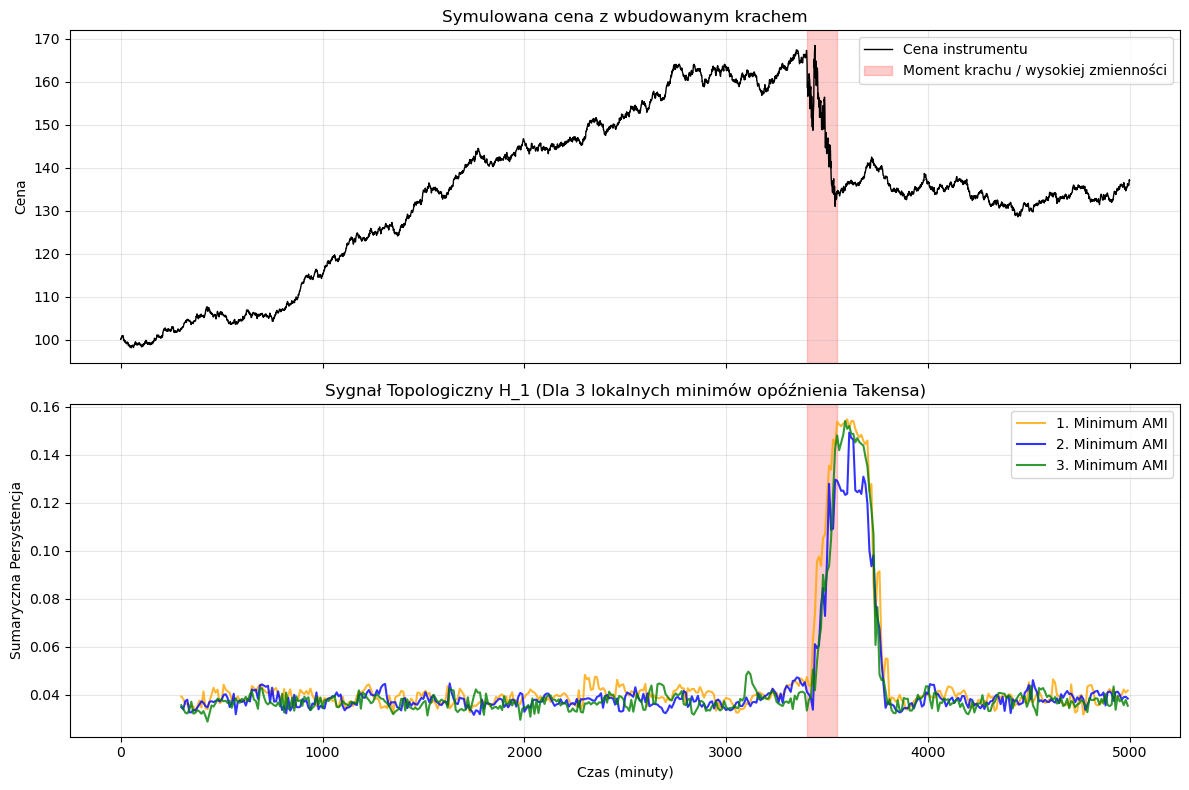

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from sklearn.metrics import mutual_info_score
from scipy.signal import find_peaks

# ==========================================
# 1. Funkcje Pomocnicze (Takens & AMI)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Zoptymalizowane wycinanie przesuniętych wektorów
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

def compute_ami(series, max_delay, bins=20):
    """Oblicza Average Mutual Information dla opóźnień od 1 do max_delay."""
    amis = []
    for tau in range(1, max_delay + 1):
        x = series[:-tau]
        y = series[tau:]
        
        # Szybkie liczenie AMI za pomocą histogramu 2D (contingency table)
        c_xy, _, _ = np.histogram2d(x, y, bins=bins)
        mi = mutual_info_score(None, None, contingency=c_xy)
        amis.append(mi)
        
    return np.array(amis)

def find_top_ami_delays(series, max_delay=30, num_peaks=3):
    """Znajduje do 'num_peaks' lokalnych minimów funkcji AMI."""
    ami_values = compute_ami(series, max_delay)
    
    # Szukamy dołków (lokalnych minimów), więc odwracamy znak tablicy
    # distance=2 zapewnia, że minima nie będą tuż obok siebie (np. tau=3 i tau=4)
    minima_indices, _ = find_peaks(-ami_values, distance=2)
    
    # Przesuwamy o +1, bo indeks 0 odpowiada tau=1
    delays = minima_indices + 1
    
    # Jeśli algorytm znajdzie mniej minimów, uzupełniamy brakujące standardowymi wartościami (np. 1, 2)
    if len(delays) == 0:
        return [1, 2, 3][:num_peaks]
    
    # Zwracamy tylko wymaganą liczbę pierwszych minimów
    return delays[:num_peaks].tolist()


# ==========================================
# 2. Generowanie Danych (Geometryczny Ruch Browna)
# ==========================================
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))
log_returns = np.diff(np.log(close_prices))


# ==========================================
# 3. Parametry eksperymentu
# ==========================================
window_size = 300    
dimension = 4        
step = 10            
max_ami_search = 30  # Szukamy minimów w oknie do tau=30

timestamps = []
# Słownik do przechowywania wyników dla 3 różnych opóźnień
h1_persistence_results = {0: [], 1: [], 2: []} 

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# ==========================================
# 4. Główna pętla z analizą 3 osadzeń
# ==========================================
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    # 4A. Dynamiczne szukanie optymalnych opóźnień dla obecnego okna
    # Zwraca listę np. [3, 7, 12]
    optimal_taus = find_top_ami_delays(window_data, max_delay=max_ami_search, num_peaks=3)
    
    # Upewniamy się, że zawsze mamy 3 wartości do zapisu (wypychamy ewentualne braki)
    while len(optimal_taus) < 3:
        optimal_taus.append(optimal_taus[-1] + 1)
        
    timestamps.append(i + window_size)
    
    # 4B. Obliczamy TDA dla każdego z 3 wyłonionych opóźnień
    for idx, tau in enumerate(optimal_taus):
        point_cloud = takens_embedding(window_data, tau, dimension)
        
        if len(point_cloud) < dimension + 1:
            h1_persistence_results[idx].append(0.0)
            continue
            
        res = ripser(point_cloud, maxdim=1)
        h1_diagram = res['dgms'][1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        h1_persistence_results[idx].append(total_pers)

print("Obliczenia zakończone.")

# ==========================================
# 5. Wizualizacja
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnałów topologicznych dla 3 różnych minimów AMI
colors = ['orange', 'blue', 'green']
labels = ['1. Minimum AMI', '2. Minimum AMI', '3. Minimum AMI']

for idx in range(3):
    ax2.plot(timestamps, h1_persistence_results[idx], label=labels[idx], color=colors[idx], linewidth=1.5, alpha=0.8)

ax2.set_title(f'Sygnał Topologiczny H_1 (Dla 3 lokalnych minimów opóźnienia Takensa)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Section 2: short term

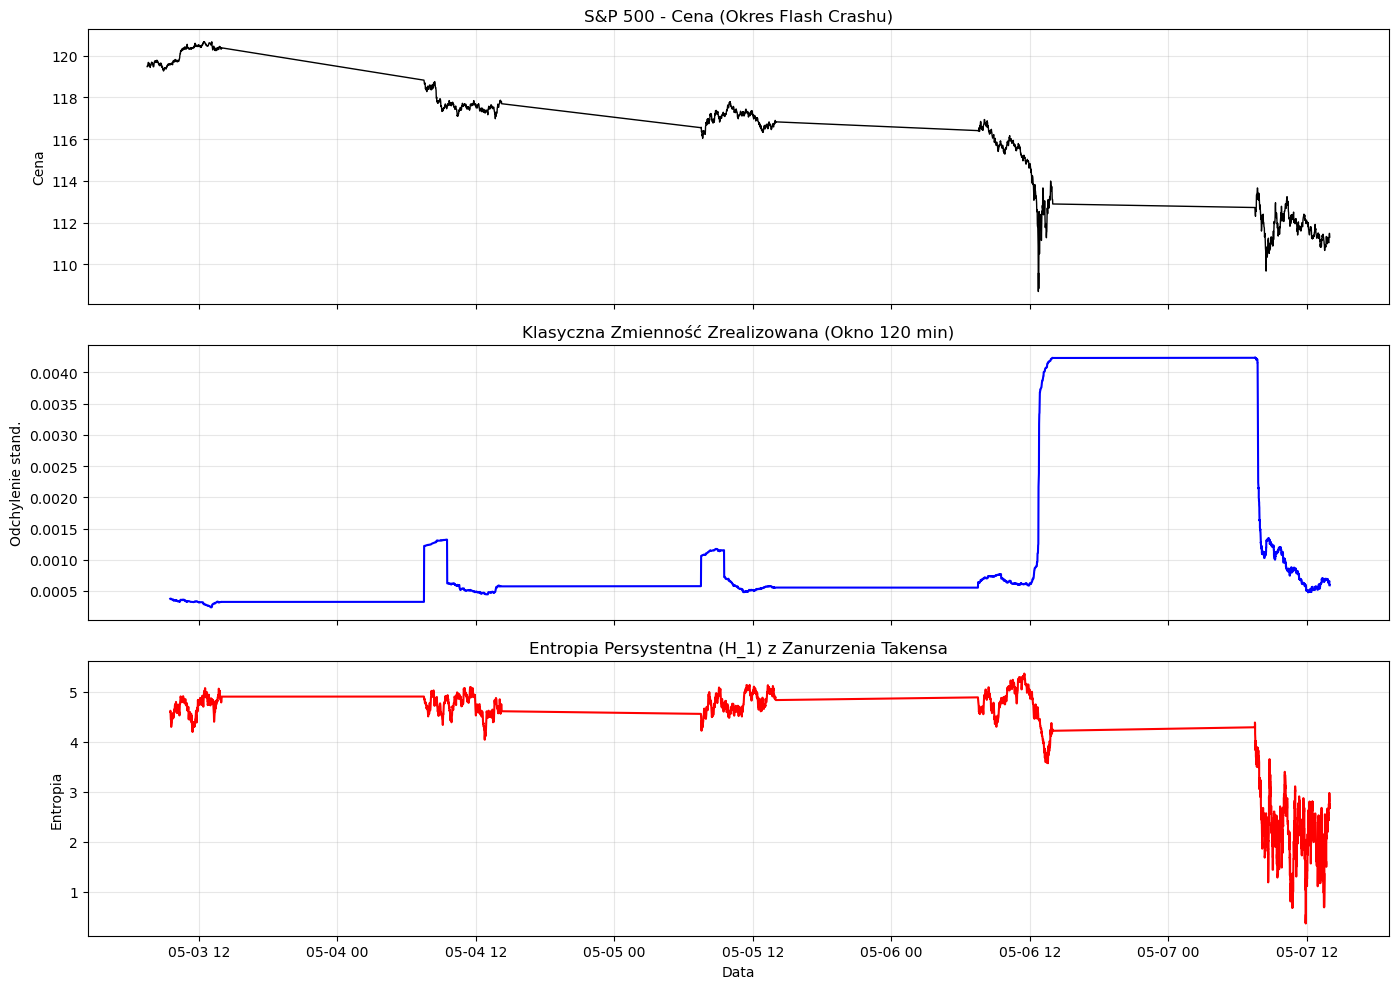

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser

# ---------------------------------------------------------
# 1. PRZYGOTOWANIE DANYCH
# ---------------------------------------------------------
# Zakładam, że masz już wczytany df. 
# Wycinamy tydzień wokół Flash Crashu (6 maja 2010)

# Sort the index to ensure it's monotonic
df = df.sort_index()

df_crash = df.loc['2010-05-03':'2010-05-07'].copy()
close_prices = df_crash['close'].values

# Przechodzimy na log-zwroty (standard w finansach, stabilizuje wariancję)
log_returns = np.diff(np.log(close_prices))
dates = df_crash.index[1:]

# ---------------------------------------------------------
# 2. PARAMETRY EKSPERYMENTU
# ---------------------------------------------------------
WINDOW_SIZE = 120      # okno 60-minutowe
DIMENSION = 5         # wymiar zanurzenia (embedding dimension)
DELAY = 10             # opóźnienie (time delay \tau)

# ---------------------------------------------------------
# 3. FUNKCJE POMOCNICZE TDA
# ---------------------------------------------------------
def takens_embedding(series, dim, delay):
    """Tworzy chmurę punktów na podstawie Twierdzenia Takensa."""
    N = len(series)
    if N - (dim - 1) * delay <= 0:
        return np.array([])
    
    embedded = np.array([series[i : i + dim * delay : delay] 
                         for i in range(N - (dim - 1) * delay)])
    return embedded

def persistent_entropy(diagram):
    """Oblicza entropię persystentną Shannona dla danego wymiaru homologicznego."""
    # Odfiltrowujemy cechy o nieskończonym czasie życia
    finite_bars = diagram[diagram[:, 1] < np.inf]
    if len(finite_bars) == 0:
        return 0.0
    
    # Długość życia (death - birth)
    lifetimes = finite_bars[:, 1] - finite_bars[:, 0]
    L = np.sum(lifetimes)
    
    if L == 0:
        return 0.0
    
    # Prawdopodobieństwa
    p = lifetimes / L
    # Entropia Shannona
    entropy = -np.sum(p * np.log2(p + 1e-12))
    return entropy

# ---------------------------------------------------------
# 4. GŁÓWNA PĘTLA - ROLLING WINDOW
# ---------------------------------------------------------
tda_entropies = np.full(len(log_returns), np.nan)
realized_volatility = np.full(len(log_returns), np.nan)

# Przesuwamy się okno po oknie
for i in range(WINDOW_SIZE, len(log_returns)):
    window_data = log_returns[i - WINDOW_SIZE : i]
    
    # Klasyczna stochastyka: Zmienność zrealizowana (odchylenie standardowe)
    realized_volatility[i] = np.std(window_data)
    
    # TDA: Zanurzenie Takensa
    point_cloud = takens_embedding(window_data, DIMENSION, DELAY)
    
    # Zabezpieczenie przed pustą chmurą
    if len(point_cloud) > 2:
        try:
            # Liczymy homologie do H_1 (połączenia i pętle)
            result = ripser(point_cloud, maxdim=1)
            diagrams = result['dgms']
            
            # Liczymy entropię dla pętli (H_1), które często oznaczają anomalie
            if len(diagrams) > 1 and len(diagrams[1]) > 0:
                tda_entropies[i] = persistent_entropy(diagrams[1])
            else:
                tda_entropies[i] = 0.0
        except Exception as e:
            tda_entropies[i] = 0.0

# ---------------------------------------------------------
# 5. WIZUALIZACJA WYNIKÓW
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Wykres 1: Cena
axs[0].plot(dates, close_prices[1:], color='black', linewidth=1)
axs[0].set_title('S&P 500 - Cena (Okres Flash Crashu)')
axs[0].set_ylabel('Cena')
axs[0].grid(True, alpha=0.3)

# Wykres 2: Klasyczna zmienność (szum stochastyczny)
axs[1].plot(dates, realized_volatility, color='blue', linewidth=1.5)
axs[1].set_title(f'Klasyczna Zmienność Zrealizowana (Okno {WINDOW_SIZE} min)')
axs[1].set_ylabel('Odchylenie stand.')
axs[1].grid(True, alpha=0.3)

# Wykres 3: Sygnał TDA (Entropia H_1)
axs[2].plot(dates, tda_entropies, color='red', linewidth=1.5)
axs[2].set_title('Entropia Persystentna (H_1) z Zanurzenia Takensa')
axs[2].set_ylabel('Entropia')
axs[2].set_xlabel('Data')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


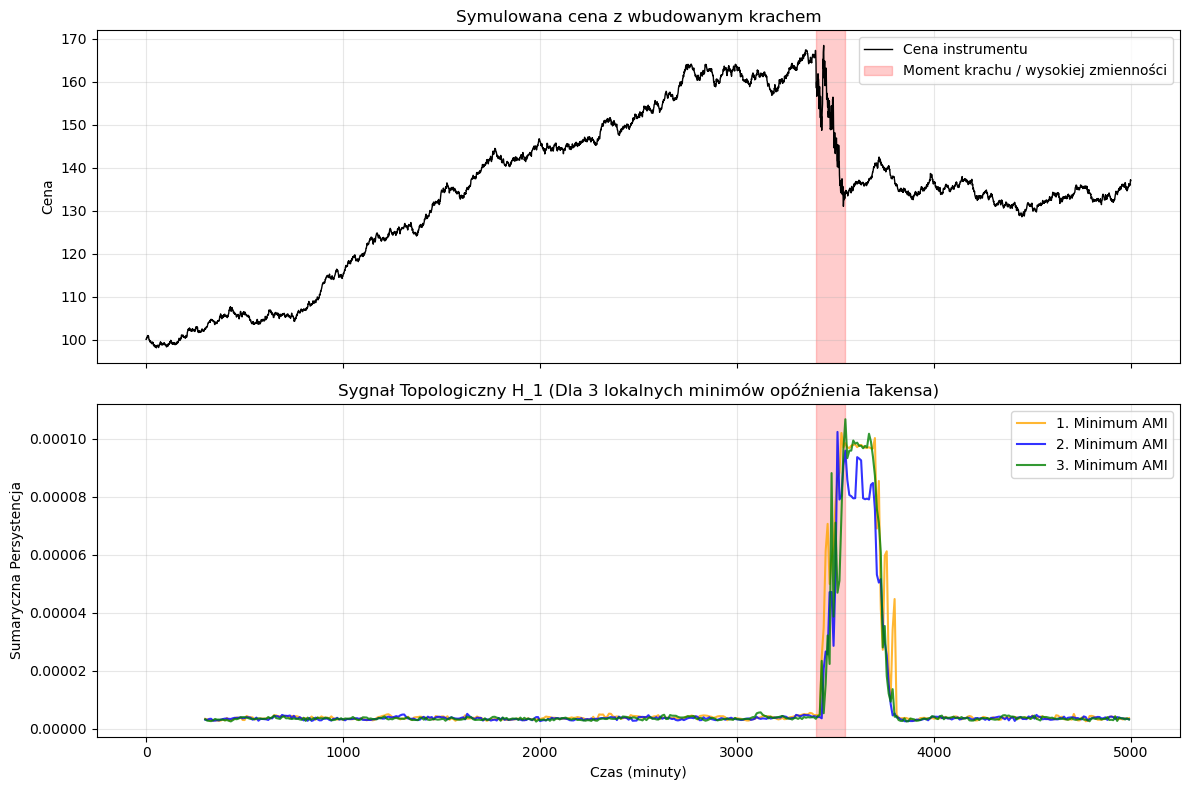

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from sklearn.metrics import mutual_info_score
from scipy.signal import find_peaks

# ==========================================
# 1. Funkcje Pomocnicze (Takens & AMI)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Zoptymalizowane wycinanie przesuniętych wektorów
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

def compute_ami(series, max_delay, bins=20):
    """Oblicza Average Mutual Information dla opóźnień od 1 do max_delay."""
    amis = []
    for tau in range(1, max_delay + 1):
        x = series[:-tau]
        y = series[tau:]
        
        # Szybkie liczenie AMI za pomocą histogramu 2D (contingency table)
        c_xy, _, _ = np.histogram2d(x, y, bins=bins)
        mi = mutual_info_score(None, None, contingency=c_xy)
        amis.append(mi)
        
    return np.array(amis)

def find_top_ami_delays(series, max_delay=30, num_peaks=3):
    """Znajduje do 'num_peaks' lokalnych minimów funkcji AMI."""
    ami_values = compute_ami(series, max_delay)
    
    # Szukamy dołków (lokalnych minimów), więc odwracamy znak tablicy
    # distance=2 zapewnia, że minima nie będą tuż obok siebie (np. tau=3 i tau=4)
    minima_indices, _ = find_peaks(-ami_values, distance=2)
    
    # Przesuwamy o +1, bo indeks 0 odpowiada tau=1
    delays = minima_indices + 1
    
    # Jeśli algorytm znajdzie mniej minimów, uzupełniamy brakujące standardowymi wartościami (np. 1, 2)
    if len(delays) == 0:
        return [1, 2, 3][:num_peaks]
    
    # Zwracamy tylko wymaganą liczbę pierwszych minimów
    return delays[:num_peaks].tolist()


# ==========================================
# 2. Generowanie Danych (Geometryczny Ruch Browna)
# ==========================================
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))
log_returns = np.diff(np.log(close_prices))


# ==========================================
# 3. Parametry eksperymentu
# ==========================================
window_size = 300    
dimension = 4        
step = 10            
max_ami_search = 30  # Szukamy minimów w oknie do tau=30

timestamps = []
# Słownik do przechowywania wyników dla 3 różnych opóźnień
h1_persistence_results = {0: [], 1: [], 2: []} 

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# ==========================================
# 4. Główna pętla (Zastosowanie Normy L1 Krajobrazu)
# ==========================================
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    optimal_taus = find_top_ami_delays(window_data, max_delay=max_ami_search, num_peaks=3)
    
    while len(optimal_taus) < 3:
        optimal_taus.append(optimal_taus[-1] + 1)
        
    timestamps.append(i + window_size)
    
    for idx, tau in enumerate(optimal_taus):
        point_cloud = takens_embedding(window_data, tau, dimension)
        
        if len(point_cloud) < dimension + 1:
            h1_persistence_results[idx].append(0.0)
            continue
            
        res = ripser(point_cloud, maxdim=1)
        h1_diagram = res['dgms'][1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                
                # --- KLUCZOWA ZMIANA: Norma L1 Krajobrazu ---
                # Zamiast zwykłej sumy (L1 na diagramie), liczymy sumę pól namiotów (L1 na krajobrazie)
                # Pole = 0.5 * podstawa(lifespan) * wysokość(lifespan/2) = lifespan^2 / 4
                tent_areas = (lifespans ** 2) / 4.0
                landscape_l1_norm = np.sum(tent_areas)
                
            else:
                landscape_l1_norm = 0.0
        else:
            landscape_l1_norm = 0.0
            
        h1_persistence_results[idx].append(landscape_l1_norm)

print("Obliczenia zakończone.")

# ==========================================
# 5. Wizualizacja
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnałów topologicznych dla 3 różnych minimów AMI
colors = ['orange', 'blue', 'green']
labels = ['1. Minimum AMI', '2. Minimum AMI', '3. Minimum AMI']

for idx in range(3):
    ax2.plot(timestamps, h1_persistence_results[idx], label=labels[idx], color=colors[idx], linewidth=1.5, alpha=0.8)

ax2.set_title(f'Sygnał Topologiczny H_1 (Dla 3 lokalnych minimów opóźnienia Takensa)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loading data...
Starting TDA rolling window analysis over 15959 data points...
Computation finished. X matrix shape: (517, 50)
Y vector shape: (517,)


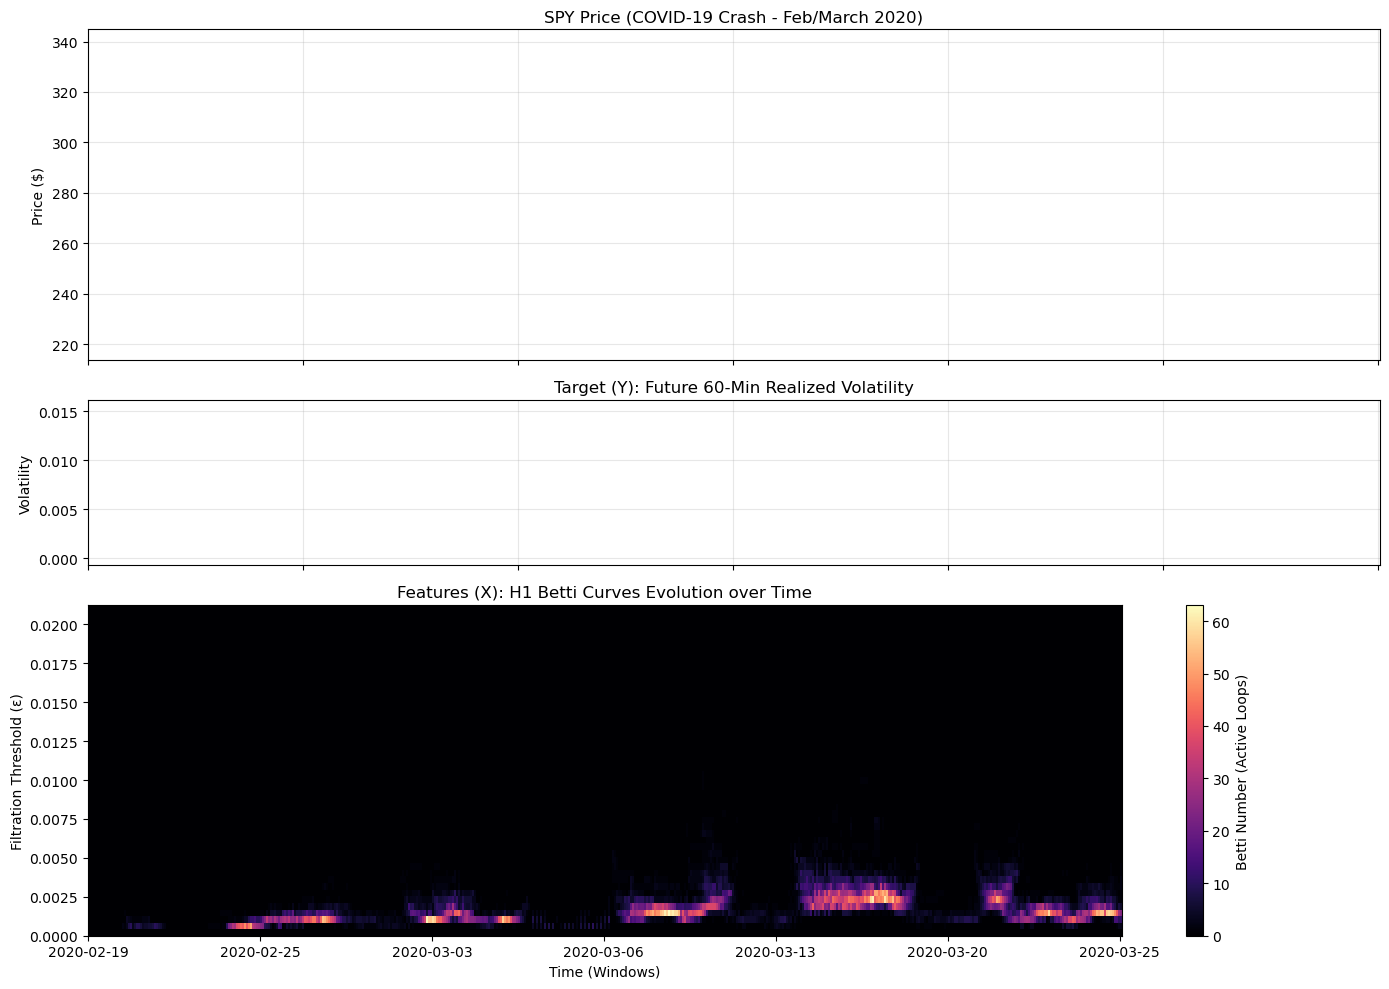

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from scipy.signal import find_peaks
from sklearn.metrics import mutual_info_score

# ==========================================
# 1. Topological Functions (Takens, AMI, Betti)
# ==========================================

def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0: return np.array([])
    return np.array([series[i : i + dimension * delay : delay] for i in range(n)])

def compute_ami(series, max_delay=30, bins=20):
    amis = []
    for tau in range(1, max_delay + 1):
        c_xy, _, _ = np.histogram2d(series[:-tau], series[tau:], bins=bins)
        amis.append(mutual_info_score(None, None, contingency=c_xy))
    return np.array(amis)

def get_optimal_delay(series, max_delay=30):
    """Finds the first local minimum of AMI to use as the delay."""
    ami_values = compute_ami(series, max_delay)
    minima, _ = find_peaks(-ami_values, distance=2)
    if len(minima) > 0:
        return minima[0] + 1
    return 1 # Fallback delay

def compute_betti_curve(diagram, epsilons):
    """
    Converts a persistence diagram into a Betti Curve (vector).
    For each epsilon, counts how many features (loops) are alive.
    """
    betti_curve = np.zeros(len(epsilons))
    if len(diagram) == 0:
        return betti_curve
    
    # Filter out features with infinite death time (if any)
    valid_features = diagram[diagram[:, 1] != np.inf]
    
    for i, eps in enumerate(epsilons):
        # A feature is alive if it was born before/at eps and dies strictly after eps
        active = np.sum((valid_features[:, 0] <= eps) & (valid_features[:, 1] > eps))
        betti_curve[i] = active
        
    return betti_curve

# ==========================================
# 2. Data Loading & Preprocessing
# ==========================================
print("Loading data...")
try:
    # Wczytanie danych
    df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
    
    # NAPRAWA BŁĘDU: Sortujemy indeks chronologicznie przed jakimkolwiek wycinaniem
    df = df.sort_index()
    
    # Focus on the COVID-19 crash: Mid-Feb to Mid-March 2020
    df = df.loc['2020-02-15':'2020-03-25']
    close_prices = df['close'].values
    timestamps = df.index
except FileNotFoundError:
    print("CSV not found. Please ensure the path is correct.")
    # Exiting safely if file is missing, replace with your actual path
    raise

# Calculate 1-minute log returns
log_returns = np.diff(np.log(close_prices))
timestamps = timestamps[1:] # Align timestamps with returns

# ==========================================
# 3. Experiment Parameters & ML Setup
# ==========================================
window_size = 390       # 1 trading day (390 minutes)
prediction_horizon = 60 # Predict volatility 1 hour ahead
dimension = 4           # Takens embedding dimension
step = 30               # Move window every 30 minutes to speed up calculations

# Discretization for the Betti Curve (the 'X' axis of our features)
# We test 50 threshold values (epsilons) between 0 and a reasonable max distance
epsilon_max = np.percentile(np.abs(log_returns), 99) * np.sqrt(dimension) * 2
epsilons = np.linspace(0, epsilon_max, 50)

# ML Dataset Arrays
X_betti_features = []
Y_future_volatility = []
plot_timestamps = []
prices_for_plot = []

print(f"Starting TDA rolling window analysis over {len(log_returns)} data points...")

# ==========================================
# 4. Main TDA Pipeline
# ==========================================
for i in range(0, len(log_returns) - window_size - prediction_horizon, step):
    
    # Current window for feature extraction (X)
    current_window = log_returns[i : i + window_size]
    
    # Future window for Target (Y) calculation
    future_window = log_returns[i + window_size : i + window_size + prediction_horizon]
    
    # 4A. Calculate optimal delay using AMI
    tau = get_optimal_delay(current_window)
    
    # 4B. Takens Embedding
    point_cloud = takens_embedding(current_window, tau, dimension)
    
    if len(point_cloud) < dimension + 1:
        continue
        
    # 4C. Persistent Homology
    res = ripser(point_cloud, maxdim=1)
    h1_diagram = res['dgms'][1]
    
    # 4D. Extract Betti Curve (Vectorization for ML)
    betti_vector = compute_betti_curve(h1_diagram, epsilons)
    
    # 4E. Calculate Target (Realized Volatility = Standard Deviation of future returns)
    future_vol = np.std(future_window)
    
    # Save to ML Dataset
    X_betti_features.append(betti_vector)
    Y_future_volatility.append(future_vol)
    plot_timestamps.append(timestamps[i + window_size])
    prices_for_plot.append(close_prices[i + window_size])

X_matrix = np.array(X_betti_features)
Y_vector = np.array(Y_future_volatility)

print("Computation finished. X matrix shape:", X_matrix.shape)
print("Y vector shape:", Y_vector.shape)

# ==========================================
# 5. Visualization: The Betti Heatmap
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1, 2]})

# Plot 1: SPY Price
ax1.plot(plot_timestamps, prices_for_plot, color='black', linewidth=1.5)
ax1.set_title('SPY Price (COVID-19 Crash - Feb/March 2020)')
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# Plot 2: Future Target (Y) - Realized Volatility
ax2.plot(plot_timestamps, Y_vector, color='red', linewidth=1)
ax2.set_title('Target (Y): Future 60-Min Realized Volatility')
ax2.set_ylabel('Volatility')
ax2.grid(True, alpha=0.3)

# Plot 3: Betti Curves Heatmap (X Features)
# Transpose X to have epsilons on Y-axis and time on X-axis
cax = ax3.imshow(X_matrix.T, aspect='auto', cmap='magma', origin='lower',
                 extent=[0, len(plot_timestamps), epsilons[0], epsilons[-1]])
ax3.set_title('Features (X): H1 Betti Curves Evolution over Time')
ax3.set_ylabel('Filtration Threshold (\u03B5)')
ax3.set_xlabel('Time (Windows)')

# Fix X-axis for the heatmap to align with dates
# We only show labels on the last axis, but imshow uses pixel coordinates, so we adjust
ticks_positions = np.linspace(0, len(plot_timestamps) - 1, 7, dtype=int)
ax3.set_xticks(ticks_positions)
ax3.set_xticklabels([plot_timestamps[i].strftime('%Y-%m-%d') for i in ticks_positions])

plt.colorbar(cax, ax=ax3, label='Betti Number (Active Loops)')
plt.tight_layout()
plt.show()

Dane treningowe (X_train): (361, 50)
Dane testowe (X_test): (156, 50)
Trenowanie modelu XGBoost na cechach topologicznych...

--- WYNIKI MODELU ---
Błąd średniokwadratowy (MSE): 0.000002
Współczynnik R^2: -0.0060 (im wyżej zera, tym lepiej model wychwytuje trend)


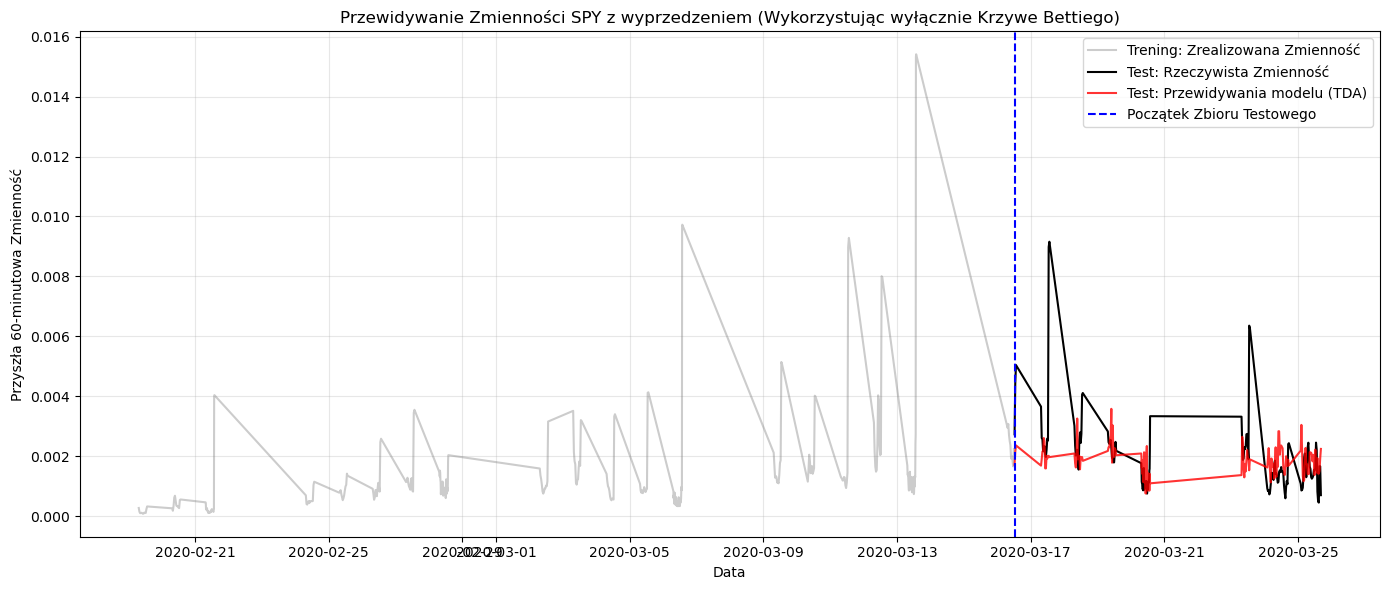

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ==========================================
# 1. Czyszczenie danych (Naprawa pustych wykresów)
# ==========================================
# Upewniamy się, że nie ma wartości NaN (np. z weekendów, braków w danych)
valid_indices = ~np.isnan(Y_vector)
X_clean = X_matrix[valid_indices]
Y_clean = Y_vector[valid_indices]
dates_clean = np.array(plot_timestamps)[valid_indices]

# ==========================================
# 2. Podział na Train / Test (BARDZO WAŻNE: chronologicznie)
# ==========================================
# Nie używamy shuffle=True, bo w finansach trenujemy na przeszłości, żeby grać na przyszłości!
split_idx = int(len(X_clean) * 0.7) # 70% danych do treningu, 30% do testów

X_train = X_clean[:split_idx]
X_test = X_clean[split_idx:]

Y_train = Y_clean[:split_idx]
Y_test = Y_clean[split_idx:]

dates_train = dates_clean[:split_idx]
dates_test = dates_clean[split_idx:]

print(f"Dane treningowe (X_train): {X_train.shape}")
print(f"Dane testowe (X_test): {X_test.shape}")

# ==========================================
# 3. Trening Modelu Machine Learning (XGBoost)
# ==========================================
print("Trenowanie modelu XGBoost na cechach topologicznych...")
# Parametry dobrane tak, by uniknąć overfittingu (max_depth=4)
model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, Y_train)

# ==========================================
# 4. Predykcja i Ewaluacja
# ==========================================
predictions = model.predict(X_test)

mse = mean_squared_error(Y_test, predictions)
r2 = r2_score(Y_test, predictions)

print(f"\n--- WYNIKI MODELU ---")
print(f"Błąd średniokwadratowy (MSE): {mse:.6f}")
print(f"Współczynnik R^2: {r2:.4f} (im wyżej zera, tym lepiej model wychwytuje trend)")

# ==========================================
# 5. Wizualizacja: Rzeczywistość vs Przewidywania TDA
# ==========================================
plt.figure(figsize=(14, 6))

# Zaznaczamy na osi czasu linię, gdzie kończy się trening a zaczyna "nieznana przyszłość" (Test)
plt.plot(dates_train, Y_train, label='Trening: Zrealizowana Zmienność', color='gray', alpha=0.4)
plt.plot(dates_test, Y_test, label='Test: Rzeczywista Zmienność', color='black', linewidth=1.5)
plt.plot(dates_test, predictions, label='Test: Przewidywania modelu (TDA)', color='red', linewidth=1.5, alpha=0.8)

plt.axvline(x=dates_clean[split_idx], color='blue', linestyle='--', label='Początek Zbioru Testowego')

plt.title('Przewidywanie Zmienności SPY z wyprzedzeniem (Wykorzystując wyłącznie Krzywe Bettiego)')
plt.xlabel('Data')
plt.ylabel('Przyszła 60-minutowa Zmienność')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()